In [3]:
import torch
from torch import nn
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import helper_functions as hlp

print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"
device

PyTorch version: 2.13.0+cu132
torchvision version: 0.28.0+cu132


'cuda'

In [4]:
DATA_DIR = "cropped_dataset"
IMG_SIZE = 128

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(root=f"{DATA_DIR}/train", transform=train_transform)
valid_data = datasets.ImageFolder(root=f"{DATA_DIR}/valid", transform=eval_transform)
test_data  = datasets.ImageFolder(root=f"{DATA_DIR}/test",  transform=eval_transform)

train_data, valid_data, test_data

(Dataset ImageFolder
     Number of datapoints: 1829
     Root location: cropped_dataset/train
     StandardTransform
 Transform: Compose(
                Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
                ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 522
     Root location: cropped_dataset/valid
     StandardTransform
 Transform: Compose(
                Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 278
     Root location: cropped_dataset/test
     StandardTransform
 Transform: Compose(
                Resize(size=(128, 128), interpolation=bilinear, max_si

In [5]:
image, label = train_data[0]
image.shape, label

(torch.Size([3, 128, 128]), 0)

In [6]:
class_names = train_data.classes
class_names

['demoman',
 'engineer',
 'heavy',
 'medic',
 'pyro',
 'scout',
 'sniper',
 'soldier',
 'spy']

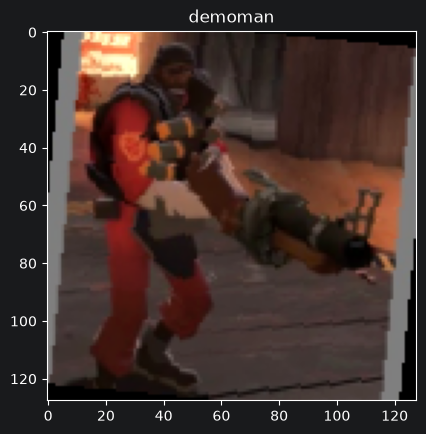

In [7]:
image, label = train_data[0]
plt.imshow(image.permute(1, 2, 0))  # [C, H, W] -> [H, W, C]
plt.title(class_names[label]);

In [8]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
valid_dataloader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
test_dataloader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train dataloader: {len(train_dataloader)} batch, each containing {BATCH_SIZE} images")
print(f"Valid dataloader: {len(valid_dataloader)} batch")
print(f"Test dataloader: {len(test_dataloader)} batch")

Train dataloader: 58 batch, each containing 32 images
Valid dataloader: 17 batch
Test dataloader: 9 batch


In [9]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 3, 128, 128]), torch.Size([32]))

In [10]:
class VisionFortressV1(nn.Module):

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.Conv2d(hidden_units*2, hidden_units*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.block_3 = nn.Sequential(
            nn.Conv2d(hidden_units*2, hidden_units*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),
            nn.Conv2d(hidden_units*4, hidden_units*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(in_features=hidden_units*4, out_features=output_shape)  # dikkat: artık hidden_units*4
        )

    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.block_3(x)
        x = self.classifier(x)
        return x

In [11]:
class_names = train_data.classes
model_0 = VisionFortressV1(input_shape=3, hidden_units=20, output_shape=len(class_names)).to(device)
model_0

VisionFortressV1(
  (block_1): Sequential(
    (0): Conv2d(3, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(20, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(20, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(20, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=Fals

In [12]:
with torch.inference_mode():
    test_output = model_0(train_features_batch.to(device))
test_output.shape

torch.Size([32, 9])

In [13]:
import torchmetrics

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_0.parameters(), lr=1e-3, weight_decay=1e-4)
accuracy_fn = torchmetrics.Accuracy(task="multiclass", num_classes=len(class_names)).to(device)

In [14]:
from tqdm.auto import tqdm

torch.manual_seed(42)

bestacc = 0

epochs = 150

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    hlp.train_step(
        model=model_0,
        data_loader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_acc = hlp.test_step(
        model=model_0,
        data_loader=valid_dataloader,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

    if test_acc > bestacc:
        bestacc = test_acc
        torch.save(model_0.state_dict(), f"models/model_0.pth")

/home/heavy/Desktop/visionfortress/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/150 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 2.1477 | Train acc: 0.1739


  1%|          | 1/150 [00:06<16:04,  6.47s/it]

Test loss: 2.1362 | Test acc: 0.1985
Epoch: 1
-------
Train loss: 2.0915 | Train acc: 0.2022


  1%|▏         | 2/150 [00:08<09:07,  3.70s/it]

...

Test loss: 1.3704 | Test acc: 0.5647
Epoch: 148
-------
Train loss: 0.6839 | Train acc: 0.7670


 99%|█████████▉| 149/150 [04:31<00:01,  1.74s/it]

Test loss: 1.2591 | Test acc: 0.6140
Epoch: 149
-------
Train loss: 0.7050 | Train acc: 0.7832


100%|██████████| 150/150 [04:33<00:00,  1.82s/it]

Test loss: 1.3641 | Test acc: 0.6029


In [15]:
best_model = VisionFortressV1(input_shape=3, hidden_units=20, output_shape=len(class_names)).to(device)
best_model.load_state_dict(torch.load("models/model_0.pth"))

<All keys matched successfully>

In [16]:
test_results = hlp.eval_model(
    model=best_model,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)
test_results

{'model_name': 'VisionFortressV1',
 'model_loss': 1.2220922708511353,
 'model_acc': 0.6395202279090881}

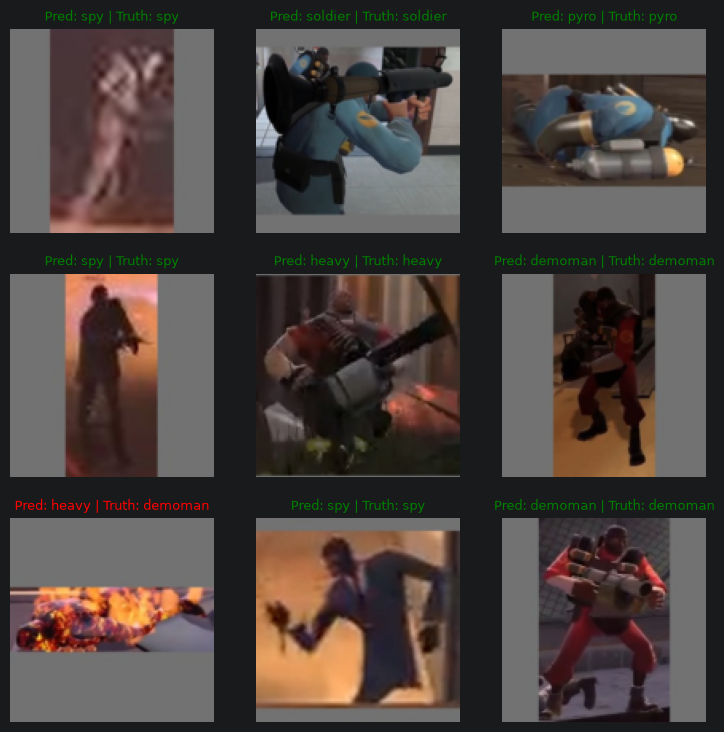

In [17]:
def make_predictions(model, data, device=device):
    model.eval()
    preds = []
    with torch.inference_mode():
        for image, label in data:
            image = image.unsqueeze(0).to(device)
            pred_logit = model(image)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)
            preds.append(pred_prob.argmax().item())
    return preds

#torch.manual_seed(42)
test_samples_idx = torch.randint(0, len(test_data), size=[9]).tolist()
test_samples = [test_data[i] for i in test_samples_idx]

"""model_1 = VisionFortressV1(
    input_shape=3,
    hidden_units=20,
    output_shape=len(class_names)
).to(device)
model_1.load_state_dict(torch.load("models/model_0.pth"))
model_1.to(device)"""

pred_classes = make_predictions(best_model, test_samples)

fig = plt.figure(figsize=(9, 9))
for i, (img, true_label) in enumerate(test_samples):
    fig.add_subplot(3, 3, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    pred_label = class_names[pred_classes[i]]
    truth_label = class_names[true_label]
    title = f"Pred: {pred_label} | Truth: {truth_label}"
    color = "green" if pred_label == truth_label else "red"
    plt.title(title, fontsize=9, c=color)
    plt.axis(False);

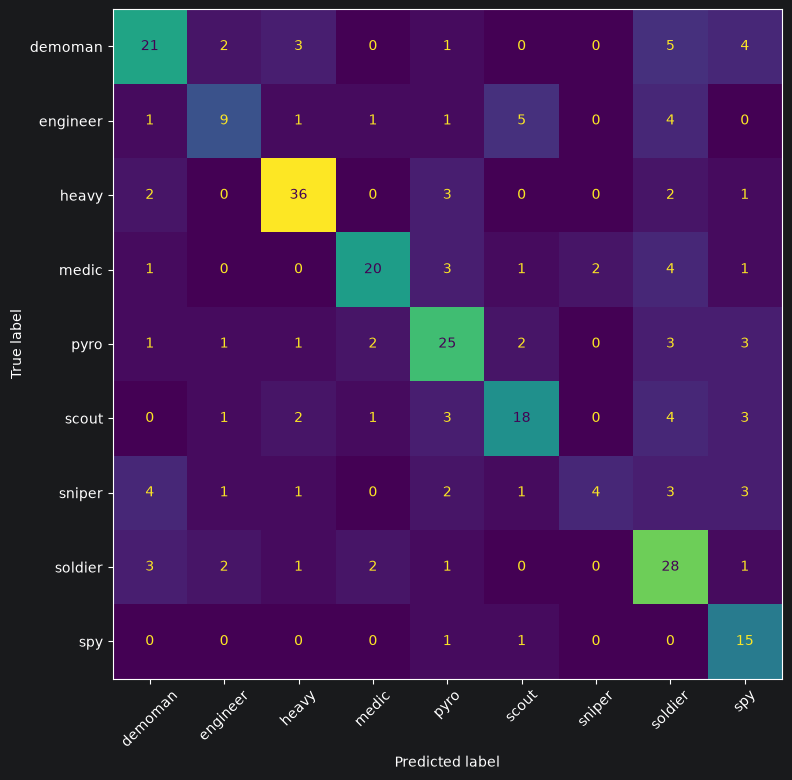

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model.eval()
all_preds = []
all_labels = []

with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        y_pred = best_model(X)
        preds = y_pred.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(y.cpu().tolist())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.tight_layout()
plt.show()

In [19]:
num_params = sum(p.numel() for p in model_0.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_params}")

Number of trainable parameters: 113709
